In [89]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))
MODEL_NAME = "gemma-4-26b-a4b-it"

In [90]:
from dataclasses import dataclass
from typing import Annotated
from typing_extensions import TypedDict
import operator

from langchain.tools import tool, ToolRuntime
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [91]:
USER_DATABASE = {
    "user123": {
        "name": "Emre",
        "balance": 5000
    },
    "user456": {
        "name": "Jawad",
        "balance": 1200
    }
}

In [92]:
@dataclass
class UserContext:
    user_id : str

In [93]:
@tool
def subtract_loan(total_balance : float , loan : float) -> float:
    """subtract the loan from total balance and return net current balance"""
    return total_balance - loan

In [94]:
@tool 
def get_account_info(runtime : ToolRuntime[UserContext]) -> str:
    """Get the current user's account information."""
    user_id = runtime.context.user_id
    user = USER_DATABASE.get(user_id)

    if not user:
        return "User not found"
    return (
        f"Name: {user['name']}\n"
        f"Balance: ${user['balance']}"
    )

In [95]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [96]:
model = ChatGoogleGenerativeAI(
    model=MODEL_NAME
)

In [97]:
tools = [subtract_loan,get_account_info]
model_with_tools = model.bind_tools(tools)

In [98]:
def llm_node(state: AgentState) -> dict:
    response = model_with_tools.invoke(
        state['messages']
    )
    return {
        'messages' : [response]
    }

In [99]:
tool_node = ToolNode(tools)

In [100]:
graph = StateGraph(AgentState)
graph.add_node('llm_node',llm_node)
graph.add_node('tool_node',tool_node)

graph.add_edge(START,'llm_node')
graph.add_conditional_edges(
    'llm_node',
    tools_condition,
    {
        "tools": "tool_node",
        "__end__": END
    }
)
graph.add_edge("tool_node", "llm_node")

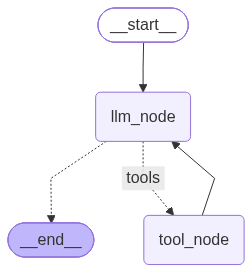

In [101]:
agent = graph.compile()
agent

In [102]:
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="What's my current balance?"
            )
        ]
    },
    context=UserContext(
        user_id="user123"
    )
)

In [103]:
result

{'messages': [HumanMessage(content="What's my current balance?", additional_kwargs={}, response_metadata={}, id='b9a7ada4-b586-49ea-9d6e-265b2f43fe37'),
  AIMessage(content=[{'type': 'thinking', 'thinking': 'The user is asking for their current balance. I should look for a tool that can provide account information, specifically the balance. The `get_account_info` tool seems appropriate for this purpose.'}], additional_kwargs={'function_call': {'name': 'get_account_info', 'arguments': '{}'}, '__gemini_function_call_thought_signatures__': {'call_219611': 'EiYKJGUyNDgzMGE3LTVjZDYtNDJmZS05OThiLWVlNTM5ZTcyYjljMw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemma-4-26b-a4b-it', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a04850-7486-7690-a938-fbfdeac692e3-0', tool_calls=[{'name': 'get_account_info', 'args': {}, 'id': 'call_219611', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 52, 'total_token

In [104]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's my current balance?
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user is asking for their current balance. I should look for a tool that can provide account information, specifically the balance. The `get_account_info` tool seems appropriate for this purpose.'}]
Tool Calls:
  get_account_info (call_219611)
 Call ID: call_219611
  Args:
================================= Tool Message =================================
Name: get_account_info

Name: Emre
Balance: $5000
================================== Ai Message ==================================

Your current balance is $5000.


In [105]:
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="subtract loan of 2000 from current balance"
            )
        ]
    },
    context=UserContext(
        user_id="user123"
    )
)

In [106]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

subtract loan of 2000 from current balance
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user wants to subtract a loan of 2000 from their current balance.\nTo do this, I first need to know the current balance.\nI should call `get_account_info` to get the account information, which should include the current balance.\nAfter I get the balance, I will use the `subtract_loan` tool.'}]
Tool Calls:
  get_account_info (call_467289)
 Call ID: call_467289
  Args:
================================= Tool Message =================================
Name: get_account_info

Name: Emre
Balance: $5000
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The current balance is $5000. The user wants to subtract a loan of 2000 from this balance.\nI will use the `subtract_loan` tool with `to

In [107]:
result = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="subtract loan of 2000 from current balance and return net total balance"
            )
        ]
    },
    context=UserContext(
        user_id="user456"
    )
)
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

subtract loan of 2000 from current balance and return net total balance
================================== Ai Message ==================================

[{'type': 'thinking', 'thinking': 'The user wants to subtract a loan of 2000 from their "current balance" and get the "net total balance".\nTo do this, I first need to find out what the "current balance" is.\nThe available tools include `get_account_info`, which seems like it would provide account details, likely including the balance.\nOnce I have the current balance, I can use the `subtract_loan` tool to perform the subtraction.\n\nStep 1: Call `get_account_info` to get the current balance.\nStep 2: Extract the balance from the response.\nStep 3: Call `subtract_loan` with `total_balance` (the balance found) and `loan` (2000).\nStep 4: Return the result to the user.'}]
Tool Calls:
  get_account_info (call_595956)
 Call ID: call_595956
  Args:
==========